In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

0. Znajdź i pobierz zbiór danych CAR EVALUATION z repozytorium danych UCI. Dowiedz się
co opisują pobrane dane.

In [2]:
names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
cars = pd.read_csv('car.data', header=None, sep=',', names=names)

   ----------------------------------------------------
   CAR                      car acceptability

   . PRICE                  overall price

   . . buying               buying price

   . . maint                price of the maintenance

   . TECH                   technical characteristics

   . . COMFORT              comfort

   . . . doors              number of doors

   . . . persons            capacity in terms of persons to carry

   . . . lug_boot           the size of luggage boot

   . . safety               estimated safety of the car


----------------------------------------------------
7. Attribute Values:

   buying       v-high, high, med, low

   maint        v-high, high, med, low

   doors        2, 3, 4, 5-more

   persons      2, 4, more

   lug_boot     small, med, big

   safety       low, med, high

----------------------------------------------------
| names file (C4.5 format) for car evaluation domain

| class values

unacc, acc, good, vgood

| attributes

buying:   vhigh, high, med, low.

maint:    vhigh, high, med, low.

doors:    2, 3, 4, 5more.

persons:  2, 4, more.

lug_boot: small, med, big.

safety:   low, med, high.

----------------------------------------------------

1. Na wykresie tortowym pokaż ile spośród wszystkich samochodów to samochody nieakcepto-
walne, akceptowalne, dobre i bardzo dobre.

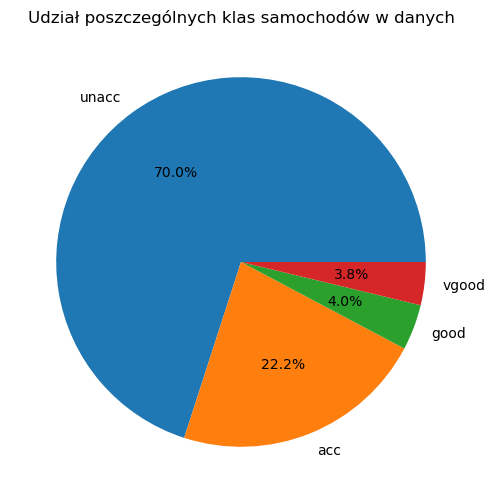

Wszystkich samochodów jest: 1728
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(6,6))

sizes = cars['class'].value_counts()
labels = sizes.index

plt.pie(sizes, labels=labels, autopct='%1.1f%%') # ten autopct (auto percentage) to pokazuje procenty x.1 oznacza 1 miejsce po przecinku, ale nie wiem za co odpowiada liczba przed kropką, bo nic nie zmienia
plt.title("Udział poszczególnych klas samochodów w danych")
plt.show()

print(f"Wszystkich samochodów jest: {len(cars)}")
print(sizes)


2. Na wykresie słupkowym pokaż ile jest samochodów 2, 3 i 4 drzwiowych w różnych klasach
bezpieczeństwa.

In [4]:
doors_2_3_4 = cars[cars['doors'].isin(['2', '3', '4'])]

counts = doors_2_3_4.groupby(["safety", "doors"]).size()

print("--------------------------------------------")

print(f"Grupy przed unstack: \n{counts} \n--------------------------------------------")

counts = doors_2_3_4.groupby(["safety", "doors"]).size().unstack(fill_value=0) 
# unstack, rozpłaszcza drugi poziom w kolumy, zamiast NaN, pojami się zero

print(f"Grupy po unstack: \n{counts} \n--------------------------------------------")


--------------------------------------------
Grupy przed unstack: 
safety  doors
high    2        144
        3        144
        4        144
low     2        144
        3        144
        4        144
med     2        144
        3        144
        4        144
dtype: int64 
--------------------------------------------
Grupy po unstack: 
doors     2    3    4
safety               
high    144  144  144
low     144  144  144
med     144  144  144 
--------------------------------------------


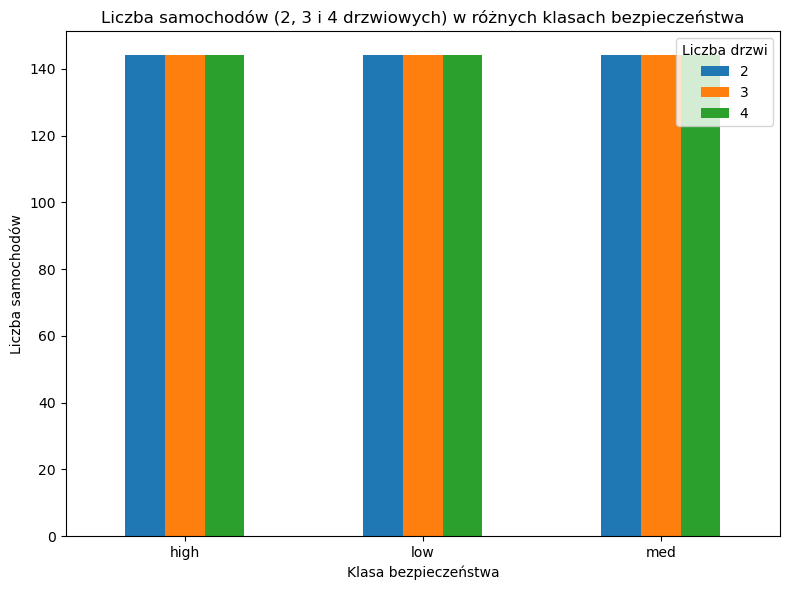

In [5]:
counts.plot(kind="bar", figsize=(8,6))
plt.title("Liczba samochodów (2, 3 i 4 drzwiowych) w różnych klasach bezpieczeństwa")
plt.xlabel("Klasa bezpieczeństwa")
plt.ylabel("Liczba samochodów")
plt.legend(title="Liczba drzwi")
plt.xticks(rotation=0) # po to żeby podpisy na osi x były to niej równoległe
plt.tight_layout()
plt.show()

3. Dowiedź się czym jest wykres radarowy (ang. radar plot), nazywany też gwiazdowym lub
pajęczynowym (ang. star plot lub spider plot), i zrób go dla 5 wybranych atrybutów danych.

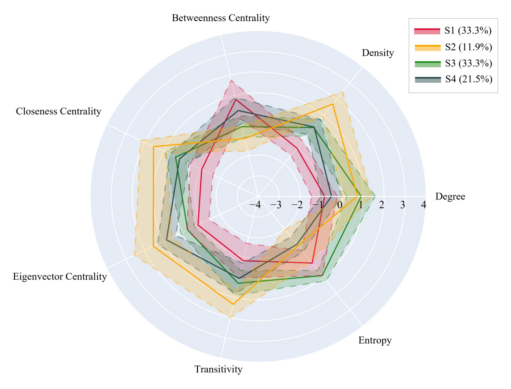

In [6]:
import matplotlib.image as mpimg

img = mpimg.imread("radar.png")
plt.imshow(img)
plt.axis("off")  # ukrywa osie
plt.show()

# Tak to powinno wyglądać
# Trzeba więc zamienić date kategoryczne na liczbowe, na szczęscie są one ozanką jakości

In [7]:
maps = {
    "buying": {"low": 1, "med": 2, "high": 3, "vhigh": 4},
    "maint": {"low": 1, "med": 2, "high": 3, "vhigh": 4},
    "doors": {"2": 2, "3": 3, "4": 4, "5more": 5},
    "persons": {"2": 2, "4": 4, "more": 5},
    "lug_boot": {"small": 1, "med": 3, "big": 5},
    "safety": {"low": 1, "med": 2, "high": 3}
}

pd.set_option('future.no_silent_downcasting', True)  # interperter kazał to dodać
df = cars.replace(maps).infer_objects(copy=False) # interperter kazał dodać infer_objects(copy=False)

categories = names[:-1]

avg_by_class = df.groupby("class")[categories].mean()

avg_norm = (avg_by_class - avg_by_class.min()) / (avg_by_class.max() - avg_by_class.min())

# normalizacja dlatego, że osie mają rózne skale i to jedyny sposób żeby te ująć wspólnie na jednym wykresie

print(avg_norm.head())

         buying     maint     doors   persons  lug_boot    safety
class                                                            
acc    0.828979  0.827499  0.417535  0.955827  0.247867  0.624130
good   0.000000  0.000000  0.351691  0.950833  0.162843  0.546777
unacc  1.000000  1.000000  0.000000  0.000000  0.000000  0.000000
vgood  0.050649  0.359050  1.000000  1.000000  1.000000  1.000000


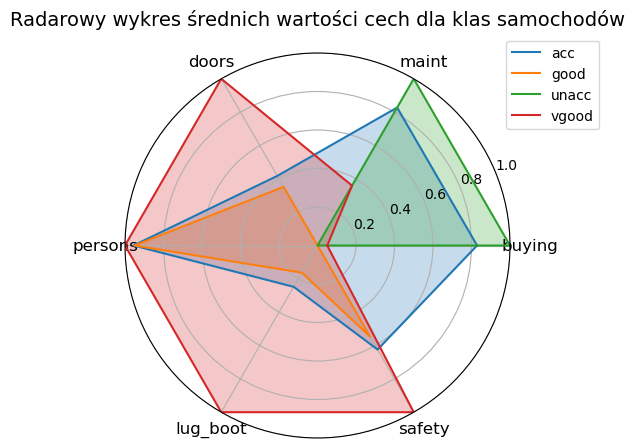

In [8]:
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # dopełniamy, żeby linia się zamknęła

plt.figure(figsize=(5, 5))
ax = plt.subplot(1,1,1, polar=True)

for idx, row in avg_norm.iterrows():
    values = row.tolist()
    values += values[:1]  # dopełniamy, żeby linia się zamknęła
    ax.plot(angles, values, label=idx)
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1]) # wyrówanie etykiet do osi
ax.set_xticklabels(categories, fontsize=12) # nadanie osią etykiet (zamist kontów)

ax.set_ylim(0, 1)

plt.title("Radarowy wykres średnich wartości cech dla klas samochodów", size=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.05))
plt.show()

4. Spróbuj określić jakie wartości jakich atrybutów decydują o tym, że samochód jest dobry
lub bardzo dobry. Zrób to intuicyjnie, według własnego pomysłu - w dalszej części wykładu
nauczysz się to robić metodami uczenia maszynowego. Sformułuj regułę, która na podstawie
wartości kilku wybranych atrybutów mówi TAK (dobry lub bardzo dobry) lub NIE. Czy Twoja
reguła działa prawidłowo dla wszystkich danych czy tylko dla części, i jak dużej części? Zrób
rysunek (według własnego pomysłu) pokazujący gdzie reguła robi błędy.

In [9]:
for cat in names[:-1]:
    result = cars[cars["class"] == "good"].groupby(cat).size()
    print(f"{cat}: {result}")

buying: buying
low    46
med    23
dtype: int64
maint: maint
low    46
med    23
dtype: int64
doors: doors
2        15
3        18
4        18
5more    18
dtype: int64
persons: persons
4       36
more    33
dtype: int64
lug_boot: lug_boot
big      24
med      24
small    21
dtype: int64
safety: safety
high    30
med     39
dtype: int64


vgood: 

    buying: nie ma high ani v-high

    maint: nie ma v-high

    persons: nie ma 2

    lug_boot: nie ma small

    safety: tylko high


good:

    buying: nie ma high ani v-high

    maint: nie ma high ani v-high

    persons: nie ma 2
    
    safety: nie ma low

In [10]:
def vgood_impossible(car):
    return car['buying'] in ['high', 'v-high'] or car['maint'] == 'v-high' or car['persons'] == '2' or car['lug_boot'] == 'small' or car['safety'] != 'high'

In [11]:
def good_impossible(car):
    return car['buying'] in ['high', 'v-high'] or car['maint'] in ['high', 'v-high'] or car['persons'] == '2' or car['safety'] == 'low'

In [12]:
from itertools import combinations

def create_rule_based_classifier(cls_good, cls_bad, threshold=0.2):
    df = cars[cars["class"].isin(cls_good+cls_bad)].copy()
    df["target"] = (df["class"].isin(cls_good)).astype(int)

    good_pairs = []

    for col1, col2 in combinations(names[:-1], 2):
        ct = pd.crosstab(df[col1], df[col2], values=df["target"], aggfunc="mean")
        for i in ct.index:
            for j in ct.columns:
                if ct.loc[i,j] >= threshold:
                    good_pairs.append(((col1, i), (col2, j)))

    good_pairs = list(set(good_pairs))
    print(f"Liczba zapisanych par: {len(good_pairs)}")
    print(f"Wybrane pary: {good_pairs}")
    return good_pairs

In [13]:
def predict(row, rules):
    for (col1, val1), (col2, val2) in rules:
        if row[col1] == val1 and row[col2] == val2:
            return 1  # good
    return 0  # other

In [14]:
good_other = create_rule_based_classifier(["good"], ["acc", "unacc", "vgood"], threshold=0.2)
vgood_other = create_rule_based_classifier(["vgood"], ["acc", "unacc", "good"], threshold=0.2)
good_vgood = create_rule_based_classifier(["good", "vgood"], ["acc", "unacc"], threshold=0.3)

Liczba zapisanych par: 3
Wybrane pary: [(('buying', 'low'), ('maint', 'med')), (('buying', 'med'), ('maint', 'low')), (('buying', 'low'), ('maint', 'low'))]
Liczba zapisanych par: 2
Wybrane pary: [(('lug_boot', 'big'), ('safety', 'high')), (('buying', 'low'), ('safety', 'high'))]
Liczba zapisanych par: 5
Wybrane pary: [(('buying', 'low'), ('maint', 'med')), (('maint', 'low'), ('safety', 'high')), (('buying', 'med'), ('maint', 'low')), (('buying', 'low'), ('maint', 'low')), (('buying', 'low'), ('safety', 'high'))]


In [15]:
def classify(car):
    if vgood_impossible(car) and good_impossible(car): # wyrzucam takie, które na 100% są other
        return 'other' 
    
    elif vgood_impossible(car): # rozważmy czy good czy other
        if predict(car, good_other) == 1:
            return 'good'
        else:
            return 'other'
        
    elif good_impossible(car): # rozważmy czy good czy other
        if predict(car, vgood_other) == 1:
            return 'vgood'
        else:
            return 'other'
    
    if predict(car, good_vgood) == 1: # reszta
        return 'good'
    
    return 'vgood'

In [16]:
def test_classification():
    results = {"vgood": {'tp': 0, 'fp': 0, 'total': 0},
                "good": {'tp': 0, 'fp': 0, 'total': 0}, 
                "other": {'tp': 0, 'fp': 0, 'total': 0}}
    for idx, row in cars.iterrows():
        cls = classify(row)
        if cls == "other" and row["class"] in ["acc", "unacc"]:
            results[cls]["tp"] += 1
        elif cls == "other" and row["class"] in ["good", "vgood"]:
            results[cls]["fp"] += 1
        elif cls in ["good", "vgood"] and row["class"] == cls:
            results[cls]["tp"] += 1
        else:
            results[cls]["fp"] += 1
        
        if row["class"] == "vgood":
            results["vgood"]["total"] += 1
        if row["class"] == "good":
            results["good"]["total"] += 1
        if row["class"] in ["acc", "unacc"]:
            results["other"]["total"] += 1

    return results


In [17]:
result = test_classification()

print("Wyniki klasyfikacji:")
for cls, res in result.items():
    precision = res['tp'] / (res['tp'] + res['fp']) if (res['tp'] + res['fp']) > 0 else 0
    recall = res['tp'] / res['total'] if res['total'] > 0 else 0
    print(f"Klasa: {cls}")
    print(f"  TP: {res['tp']}")
    print(f"  FP: {res['fp']}")
    print(f"  TOTAL: {res['total']}")
    print(f"  PRECISION: {precision:.2%}")
    print(f"  RECALL: {recall:.2%}")
    print()

Wyniki klasyfikacji:
Klasa: vgood
  TP: 26
  FP: 70
  TOTAL: 65
  PRECISION: 27.08%
  RECALL: 40.00%

Klasa: good
  TP: 69
  FP: 107
  TOTAL: 69
  PRECISION: 39.20%
  RECALL: 100.00%

Klasa: other
  TP: 1456
  FP: 0
  TOTAL: 1594
  PRECISION: 100.00%
  RECALL: 91.34%

